## Bibliothéques importés

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector
from statsmodels.graphics.mosaicplot import mosaic

## Connection BDD

In [27]:
def getBDD():
    try:
        return mysql.connector.connect(
            host='localhost', database='gamesale',
            user='root', password='', charset='utf8'
        )
    except Exception as e:
        print(f"Connection Error: {e}")
        return None

## Fonction Mosaique Plot

In [66]:
def plot_mosaic(table_x, col_x, table_y, col_y, top_n_x=5, top_n_y=4, custom_title=None):
    connect = getBDD()
    if not connect: return

    joins = {
        'genre': 'JOIN genre ON jeux.id_jeu = genre.id_jeu',
        'editeur': 'JOIN editeur ON jeux.id_jeu = editeur.id_jeu',
        'developpeur': 'JOIN developpeur ON jeux.id_jeu = developpeur.id_jeu',
        'categorie': 'JOIN a_categorie ON jeux.id_jeu = a_categorie.id_jeu JOIN categorie ON a_categorie.id_cat = categorie.id_cat',
        'os': 'JOIN a_os ON jeux.id_jeu = a_os.id_jeu JOIN os ON a_os.id_os = os.id_os'
    }

    needed_joins = set()
    if table_x != 'jeux' and table_x in joins: needed_joins.add(joins[table_x])
    if table_y != 'jeux' and table_y in joins: needed_joins.add(joins[table_y])

    sql_from = f"jeux {' '.join(needed_joins)}"
    sql = f"SELECT {table_x}.{col_x}, {table_y}.{col_y} FROM {sql_from}"

    df = pd.read_sql(sql, connect)
    connect.close()

    for col in [col_x, col_y]:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].str.split(';')
        df = df.explode(col)
        df[col] = df[col].str.strip().str.title()

        df = df[df[col] != '']
        df = df[df[col].str.lower() != 'nan']

    df = df.dropna(subset=[col_x, col_y])

    top_x = df[col_x].value_counts().head(top_n_x).index
    top_y = df[col_y].value_counts().head(top_n_y).index

    df = df[df[col_x].isin(top_x) & df[col_y].isin(top_y)]

    #filtrer les valeurs uniques restantes pour éviter les erreurs de mosaic plot
    surviving_x = df[col_x].unique()
    surviving_y = df[col_y].unique()

    if col_x.lower() == 'annee':
        order_x = sorted(surviving_x) 
    else:
        order_x = [x for x in top_x if x in surviving_x]

    if col_y.lower() == 'annee':
        order_y = sorted(surviving_y)
    else:
        order_y = [y for y in top_y if y in surviving_y]

    df[col_x] = pd.Categorical(df[col_x], categories=order_x, ordered=True)
    df[col_y] = pd.Categorical(df[col_y], categories=order_y, ordered=True)
    df = df.sort_values(by=[col_x, col_y])

    final_title = custom_title if custom_title else f"Relation entre {col_x.title()} et {col_y.title()}"

    plt.rcParams['figure.figsize'] = (14, 10)
    plt.rcParams['font.size'] = 10
    mosaic(df, [col_x, col_y], gap=0.02, title=final_title, labelizer=lambda key: "")
    plt.show()
    return df

## Année et Genre

C:\Users\Ica\AppData\Local\Temp\ipykernel_13964\3716691507.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


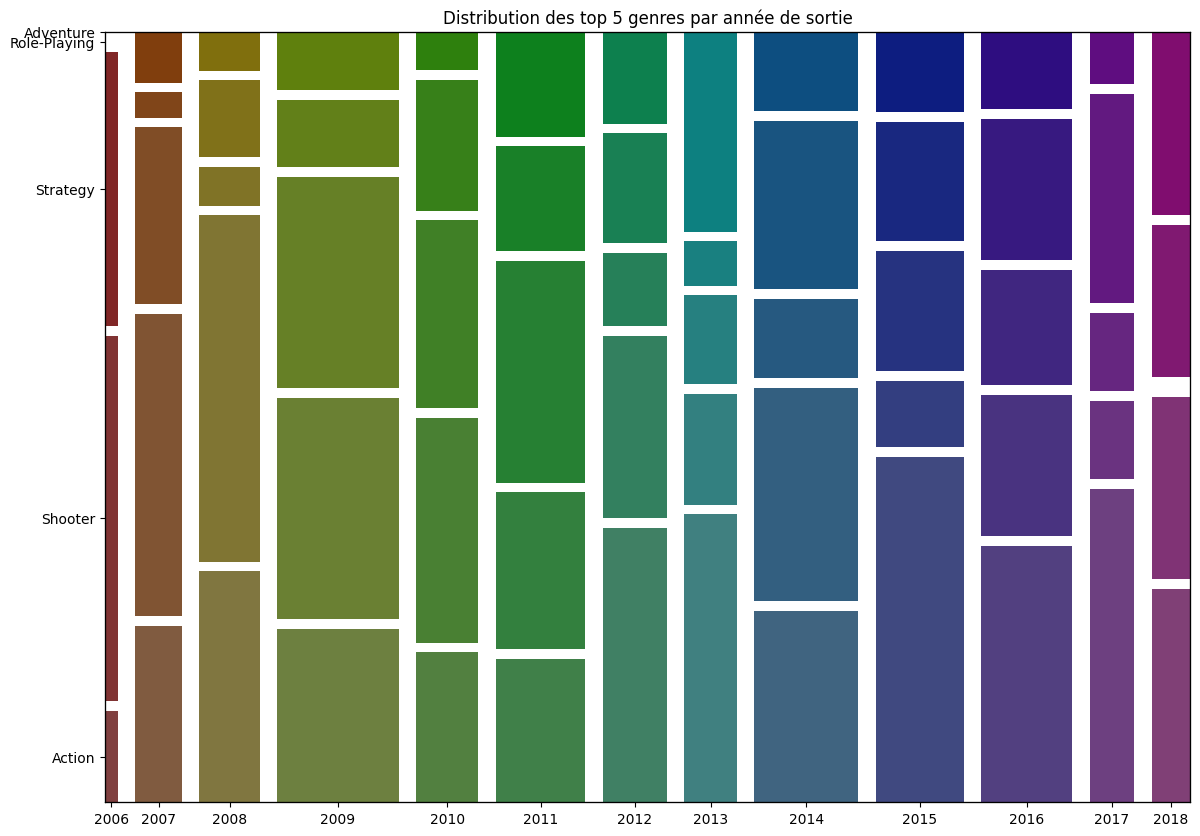

,annee,genre
463,2006,Action
83,2006,Shooter
157,2006,Shooter
291,2006,Shooter
347,2006,Shooter
...,...,...
452,2018,Adventure
501,2018,Adventure
599,2018,Adventure
606,2018,Adventure


In [71]:
plot_mosaic('jeux', 'annee', 'genre', 'genre', top_n_x=13, top_n_y=5, custom_title="Distribution des top 5 genres par année de sortie")

## Année et Editeur

C:\Users\Ica\AppData\Local\Temp\ipykernel_13964\3716691507.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


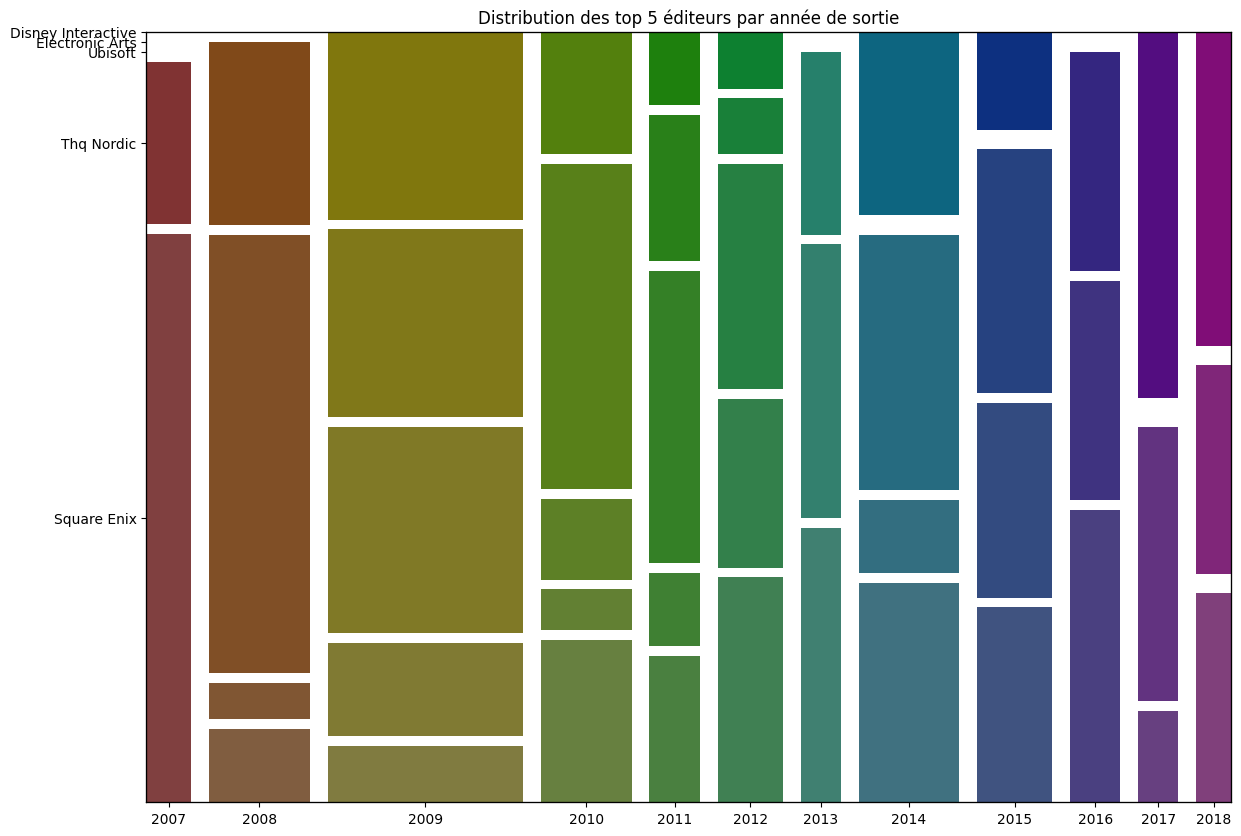

,annee,editeur
200,2007,Square Enix
258,2007,Square Enix
318,2007,Square Enix
351,2007,Square Enix
382,2007,Square Enix
...,...,...
70,2018,Square Enix
94,2018,Square Enix
46,2018,Disney Interactive
408,2018,Disney Interactive


In [67]:
plot_mosaic('jeux', 'annee', 'editeur', 'editeur', top_n_x=13, top_n_y=5, custom_title="Distribution des top 5 éditeurs par année de sortie")

## Année et Développeur

C:\Users\Ica\AppData\Local\Temp\ipykernel_13964\3716691507.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


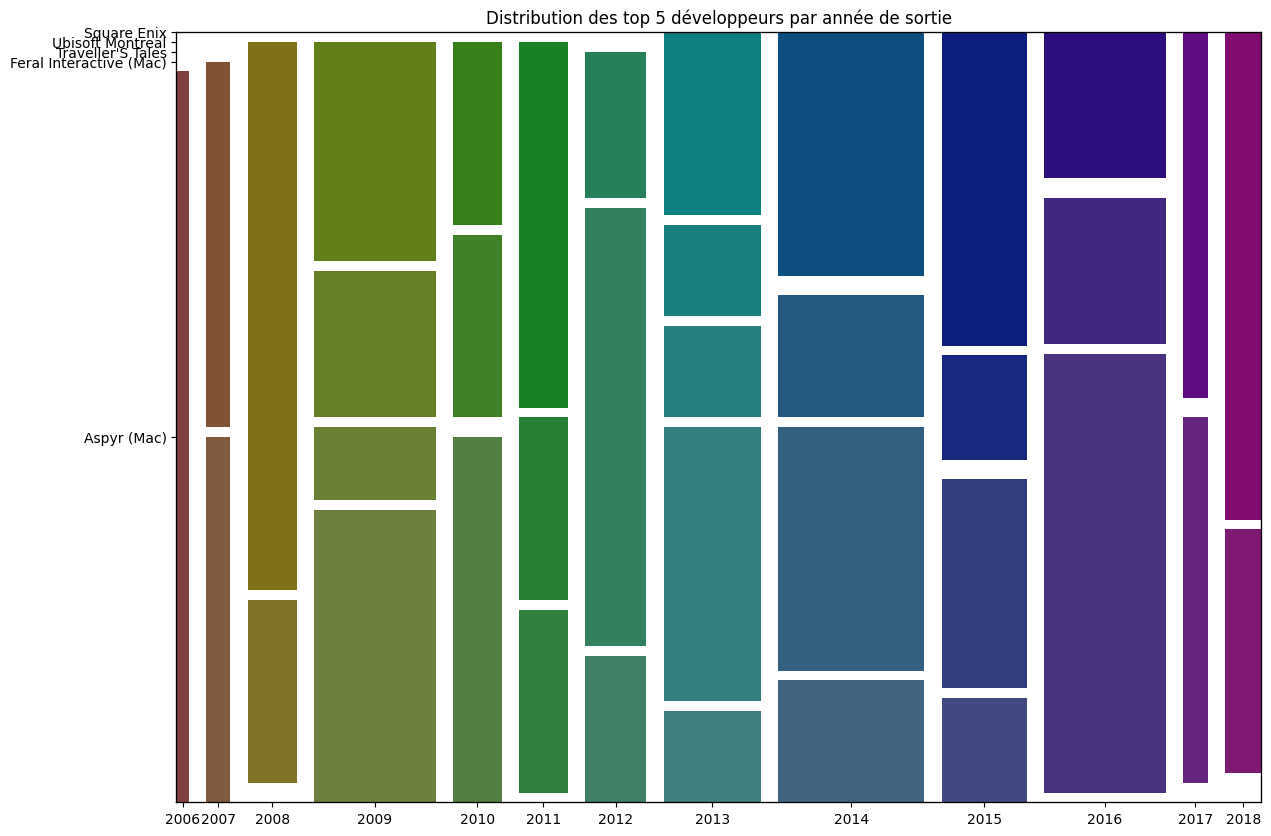

,annee,developpeur
83,2006,Aspyr (Mac)
200,2007,Feral Interactive (Mac)
10,2007,Aspyr (Mac)
40,2008,Traveller'S Tales
66,2008,Ubisoft Montreal
...,...,...
159,2017,Square Enix
126,2017,Traveller'S Tales
70,2018,Square Enix
94,2018,Square Enix


In [68]:
plot_mosaic('jeux', 'annee', 'developpeur', 'developpeur', top_n_x=13, top_n_y=5, custom_title="Distribution des top 5 développeurs par année de sortie")

## Année et OS

C:\Users\Ica\AppData\Local\Temp\ipykernel_13964\3716691507.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


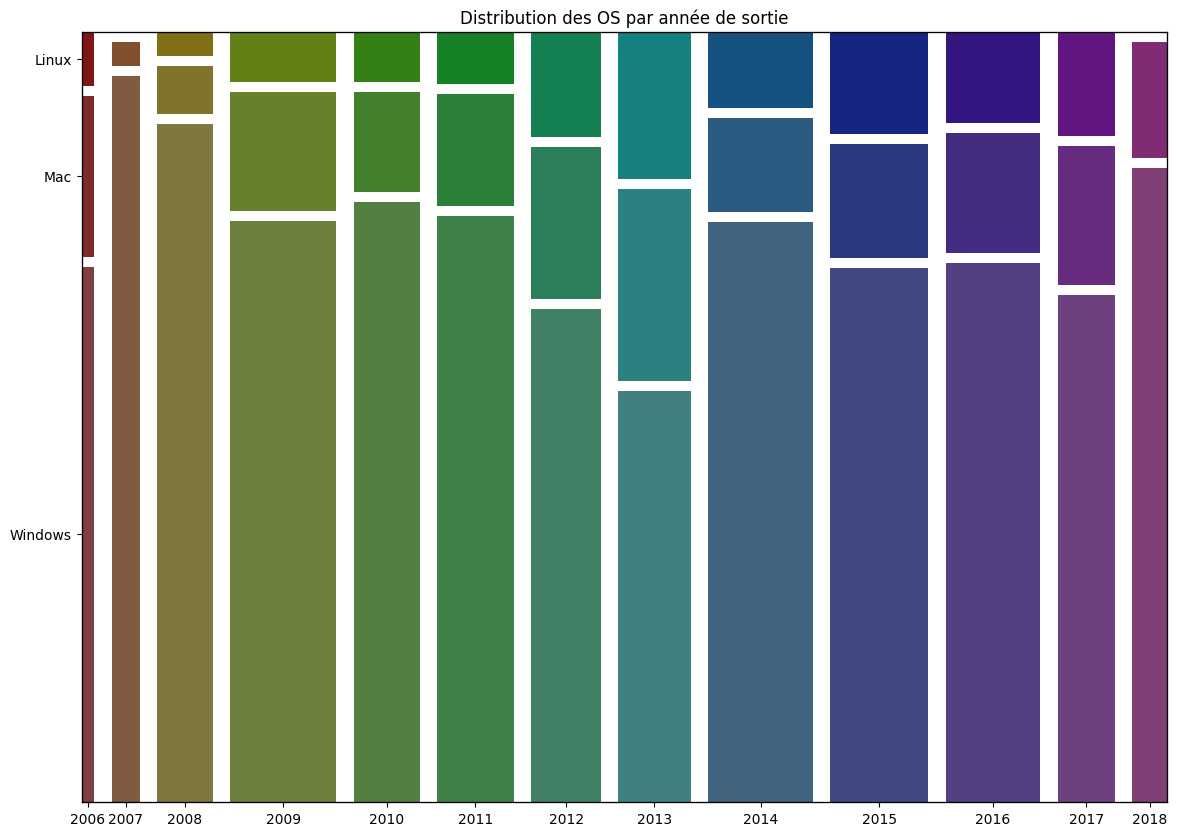

,annee,os
108,2006,Windows
204,2006,Windows
368,2006,Windows
448,2006,Windows
540,2006,Windows
...,...,...
444,2018,Mac
582,2018,Mac
605,2018,Mac
795,2018,Mac


In [69]:
plot_mosaic('jeux', 'annee', 'os', 'os', top_n_x=13, top_n_y=3, custom_title="Distribution des OS par année de sortie")

## Année et Catégorie

C:\Users\Ica\AppData\Local\Temp\ipykernel_13964\3716691507.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


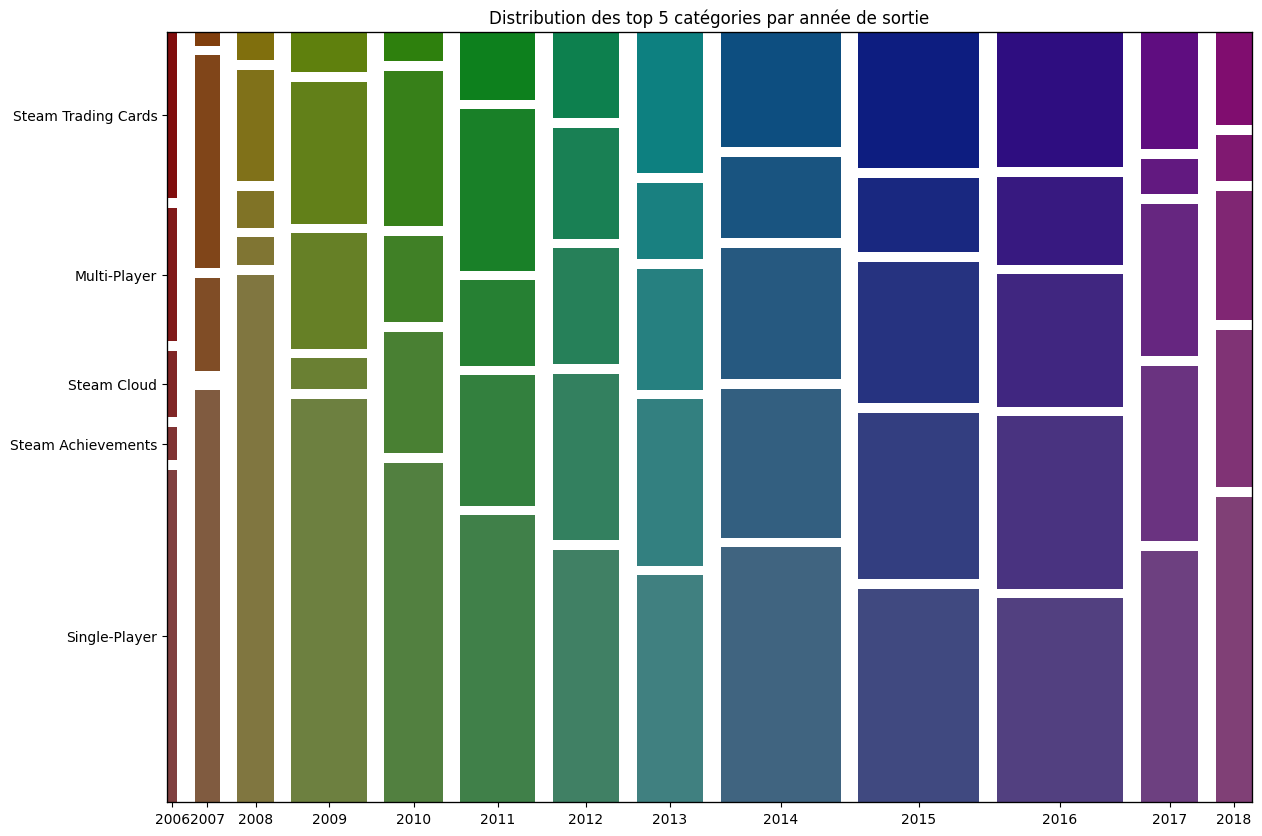

,annee,categorie
325,2006,Single-Player
606,2006,Single-Player
1109,2006,Single-Player
1347,2006,Single-Player
1630,2006,Single-Player
...,...,...
1671,2018,Steam Trading Cards
1698,2018,Steam Trading Cards
1961,2018,Steam Trading Cards
2349,2018,Steam Trading Cards


In [70]:
plot_mosaic('jeux', 'annee', 'categorie', 'categorie', top_n_x=13, top_n_y=5, custom_title="Distribution des top 5 catégories par année de sortie")

## Développeur et Genre

C:\Users\Ica\AppData\Local\Temp\ipykernel_13964\3716691507.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


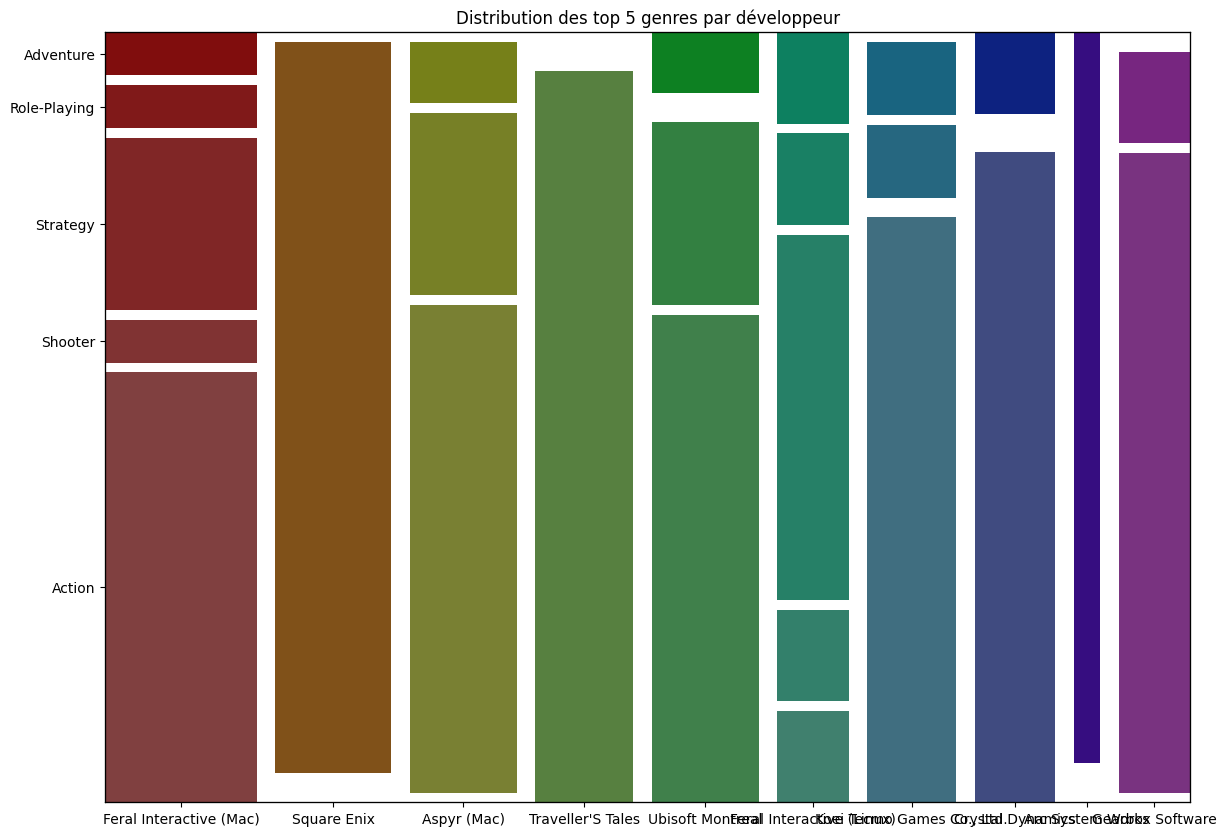

,developpeur,genre
16,Feral Interactive (Mac),Action
21,Feral Interactive (Mac),Action
74,Feral Interactive (Mac),Action
117,Feral Interactive (Mac),Action
140,Feral Interactive (Mac),Action
...,...,...
217,Gearbox Software,Shooter
235,Gearbox Software,Shooter
274,Gearbox Software,Shooter
370,Gearbox Software,Shooter


In [72]:
plot_mosaic('developpeur', 'developpeur', 'genre', 'genre', top_n_x=10, top_n_y=5, custom_title="Distribution des top 5 genres par les top 10 développeurs")

## Développeur et Genre

C:\Users\Ica\AppData\Local\Temp\ipykernel_13964\3716691507.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


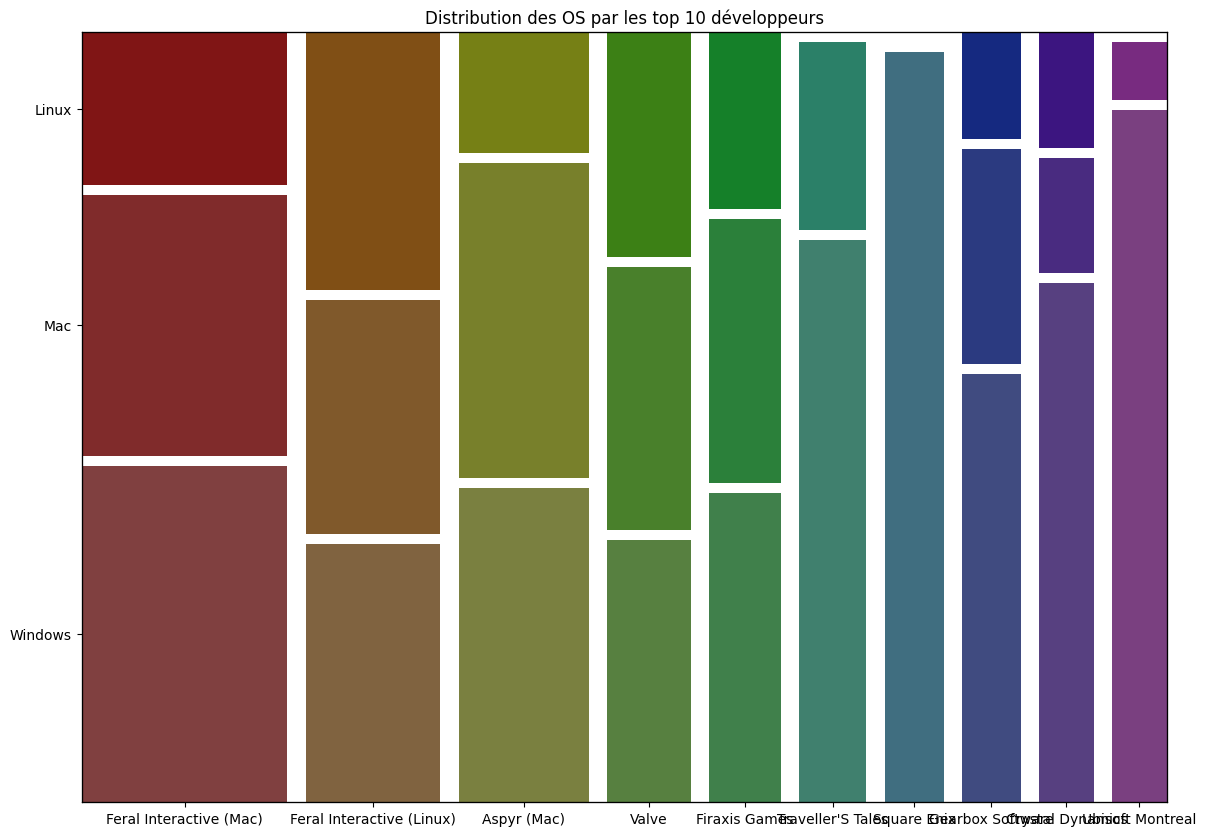

,developpeur,os
18,Feral Interactive (Mac),Windows
24,Feral Interactive (Mac),Windows
93,Feral Interactive (Mac),Windows
159,Feral Interactive (Mac),Windows
185,Feral Interactive (Mac),Windows
...,...,...
267,Ubisoft Montreal,Windows
288,Ubisoft Montreal,Windows
292,Ubisoft Montreal,Windows
795,Ubisoft Montreal,Windows


In [73]:
plot_mosaic('developpeur', 'developpeur', 'os', 'os', top_n_x=10, top_n_y=5, custom_title="Distribution des OS par les top 10 développeurs")

## Développeur et Catégorie

C:\Users\Ica\AppData\Local\Temp\ipykernel_13964\3716691507.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


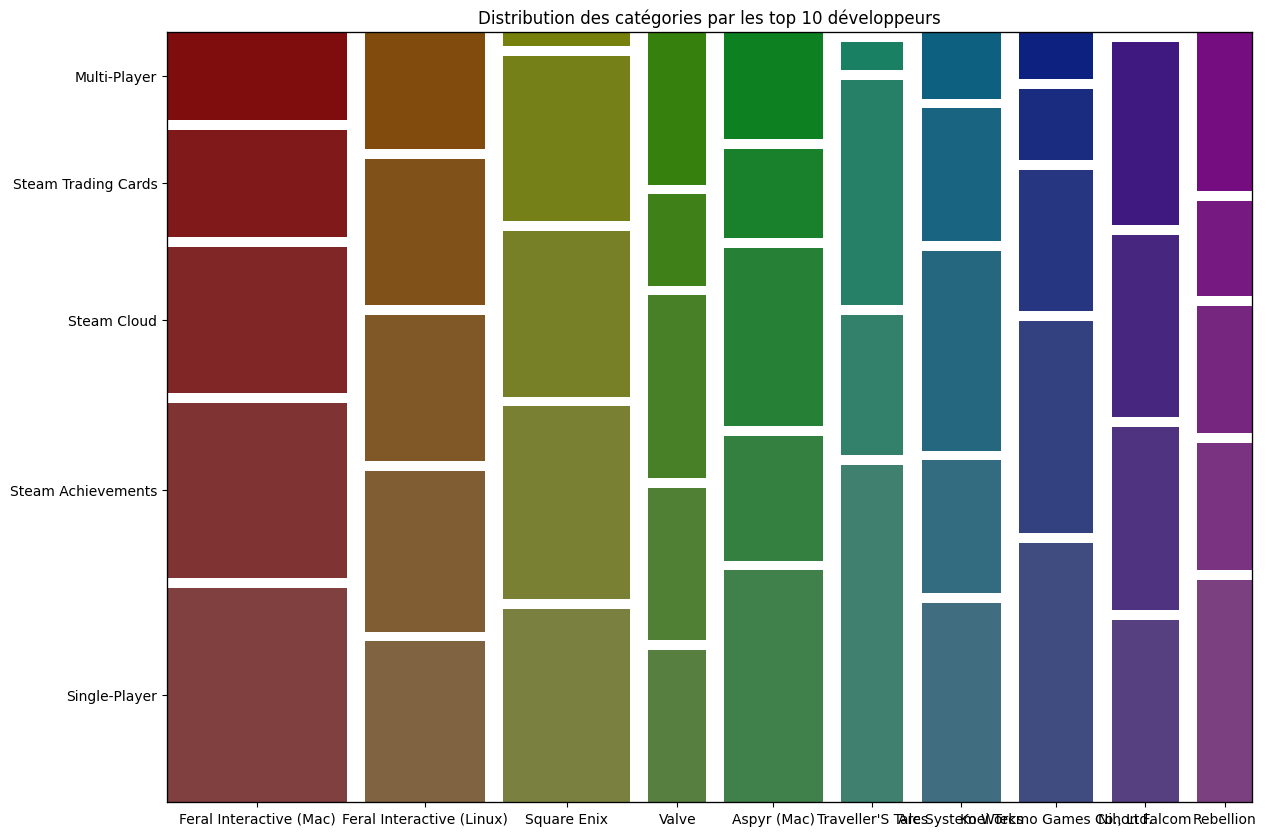

,developpeur,categorie
63,Feral Interactive (Mac),Single-Player
80,Feral Interactive (Mac),Single-Player
282,Feral Interactive (Mac),Single-Player
458,Feral Interactive (Mac),Single-Player
542,Feral Interactive (Mac),Single-Player
...,...,...
678,Rebellion,Multi-Player
886,Rebellion,Multi-Player
1757,Rebellion,Multi-Player
2428,Rebellion,Multi-Player


In [74]:
plot_mosaic('developpeur', 'developpeur', 'categorie', 'categorie', top_n_x=10, top_n_y=5, custom_title="Distribution des catégories par les top 10 développeurs")

## Editeur et Genre

C:\Users\Ica\AppData\Local\Temp\ipykernel_13964\3716691507.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


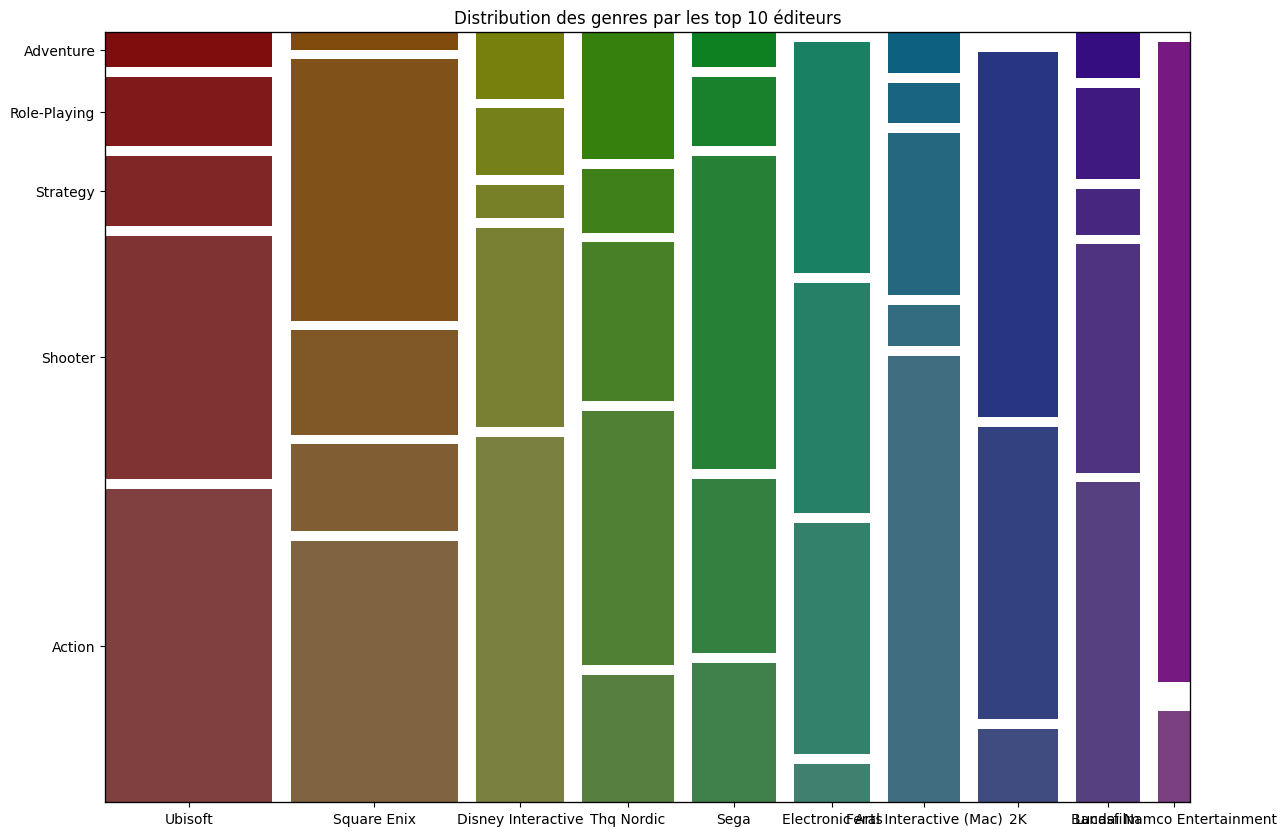

,editeur,genre
22,Ubisoft,Action
28,Ubisoft,Action
29,Ubisoft,Action
35,Ubisoft,Action
43,Ubisoft,Action
...,...,...
168,Bandai Namco Entertainment,Role-Playing
242,Bandai Namco Entertainment,Role-Playing
275,Bandai Namco Entertainment,Role-Playing
300,Bandai Namco Entertainment,Role-Playing


In [78]:
plot_mosaic('editeur', 'editeur', 'genre', 'genre', top_n_x=10, top_n_y=5, custom_title="Distribution des genres par les top 10 éditeurs")

## Editeur et OS

C:\Users\Ica\AppData\Local\Temp\ipykernel_13964\3716691507.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


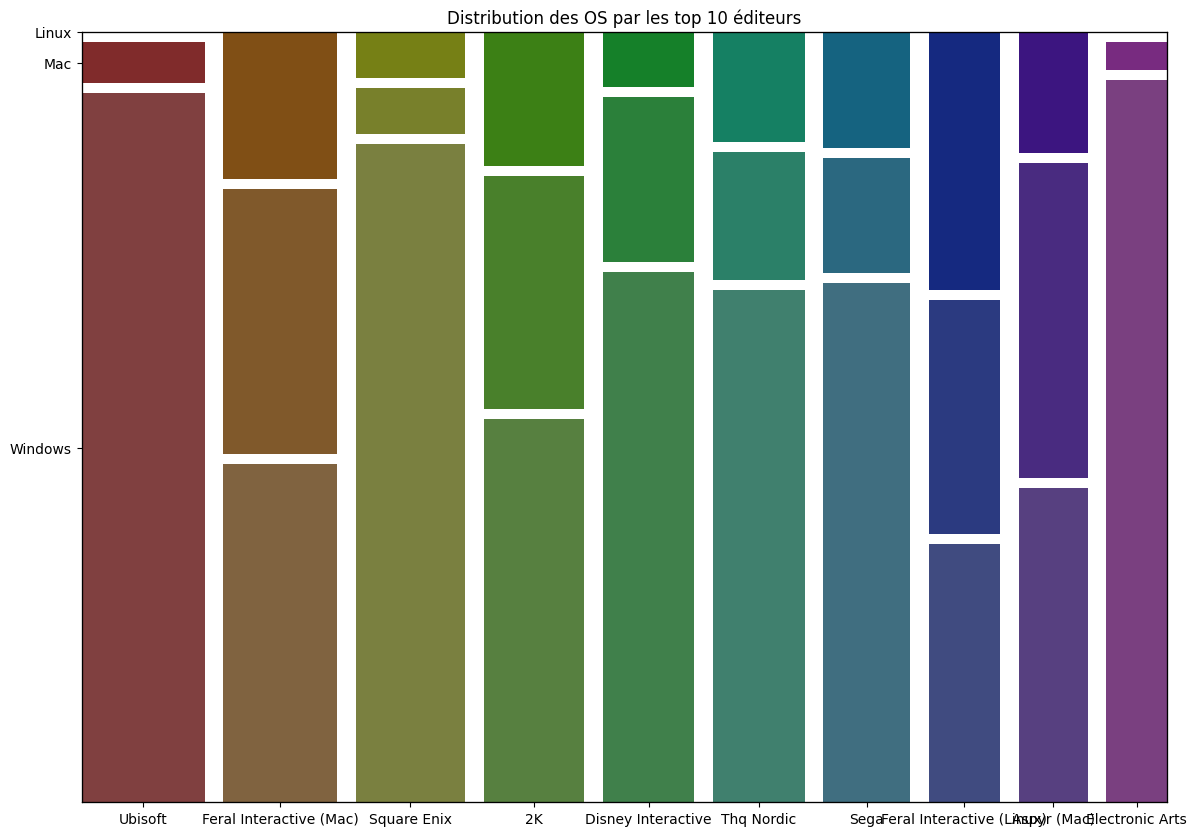

,editeur,os
27,Ubisoft,Windows
33,Ubisoft,Windows
37,Ubisoft,Windows
38,Ubisoft,Windows
42,Ubisoft,Windows
...,...,...
729,Electronic Arts,Windows
971,Electronic Arts,Windows
994,Electronic Arts,Windows
1041,Electronic Arts,Windows


In [77]:
plot_mosaic('editeur', 'editeur', 'os', 'os', top_n_x=10, top_n_y=5, custom_title="Distribution des OS par les top 10 éditeurs")

## Editeur et Catégorie

C:\Users\Ica\AppData\Local\Temp\ipykernel_13964\3716691507.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


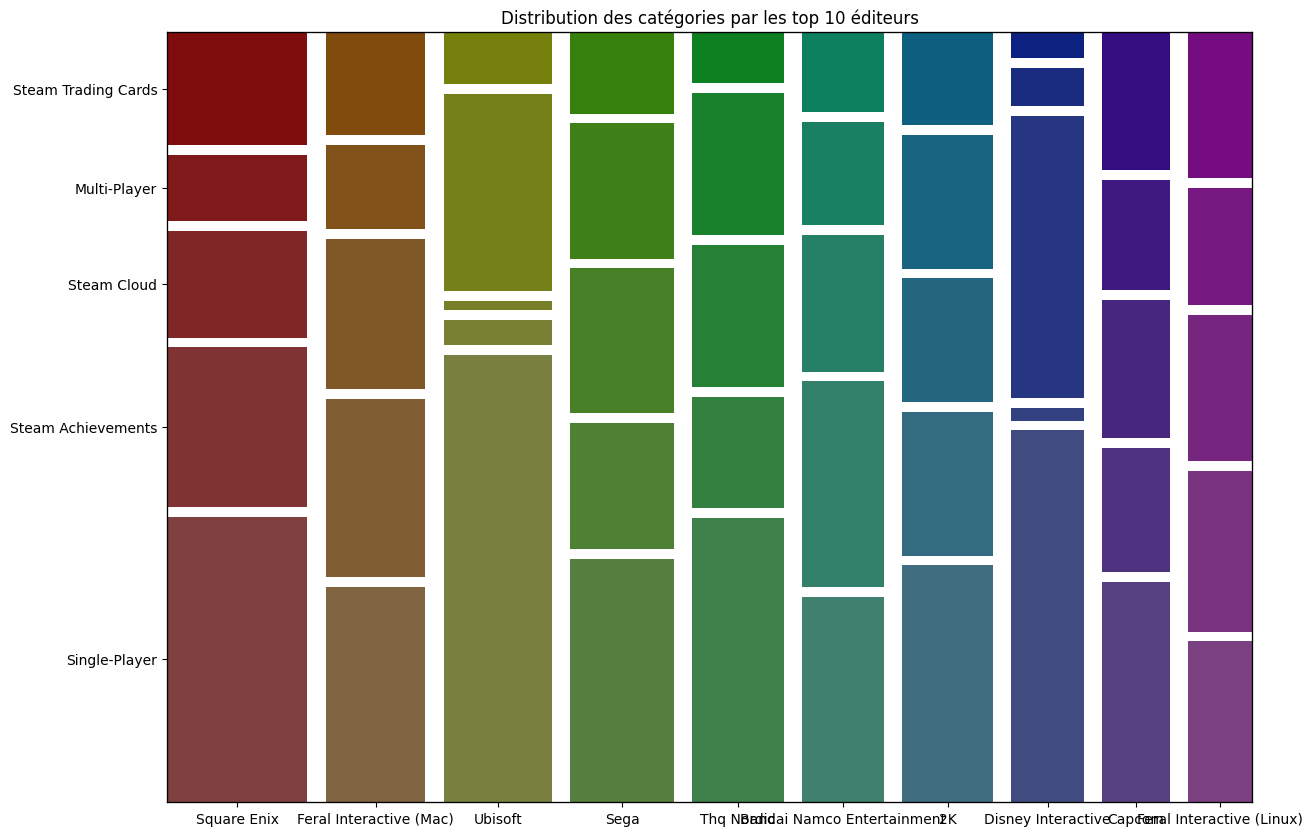

,editeur,categorie
40,Square Enix,Single-Player
52,Square Enix,Single-Player
67,Square Enix,Single-Player
72,Square Enix,Single-Player
77,Square Enix,Single-Player
...,...,...
1228,Feral Interactive (Linux),Steam Trading Cards
1260,Feral Interactive (Linux),Steam Trading Cards
1485,Feral Interactive (Linux),Steam Trading Cards
1510,Feral Interactive (Linux),Steam Trading Cards


In [79]:
plot_mosaic('editeur', 'editeur', 'categorie', 'categorie', top_n_x=10, top_n_y=5, custom_title="Distribution des catégories par les top 10 éditeurs")

## OS et Catégorie

C:\Users\Ica\AppData\Local\Temp\ipykernel_13964\3716691507.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


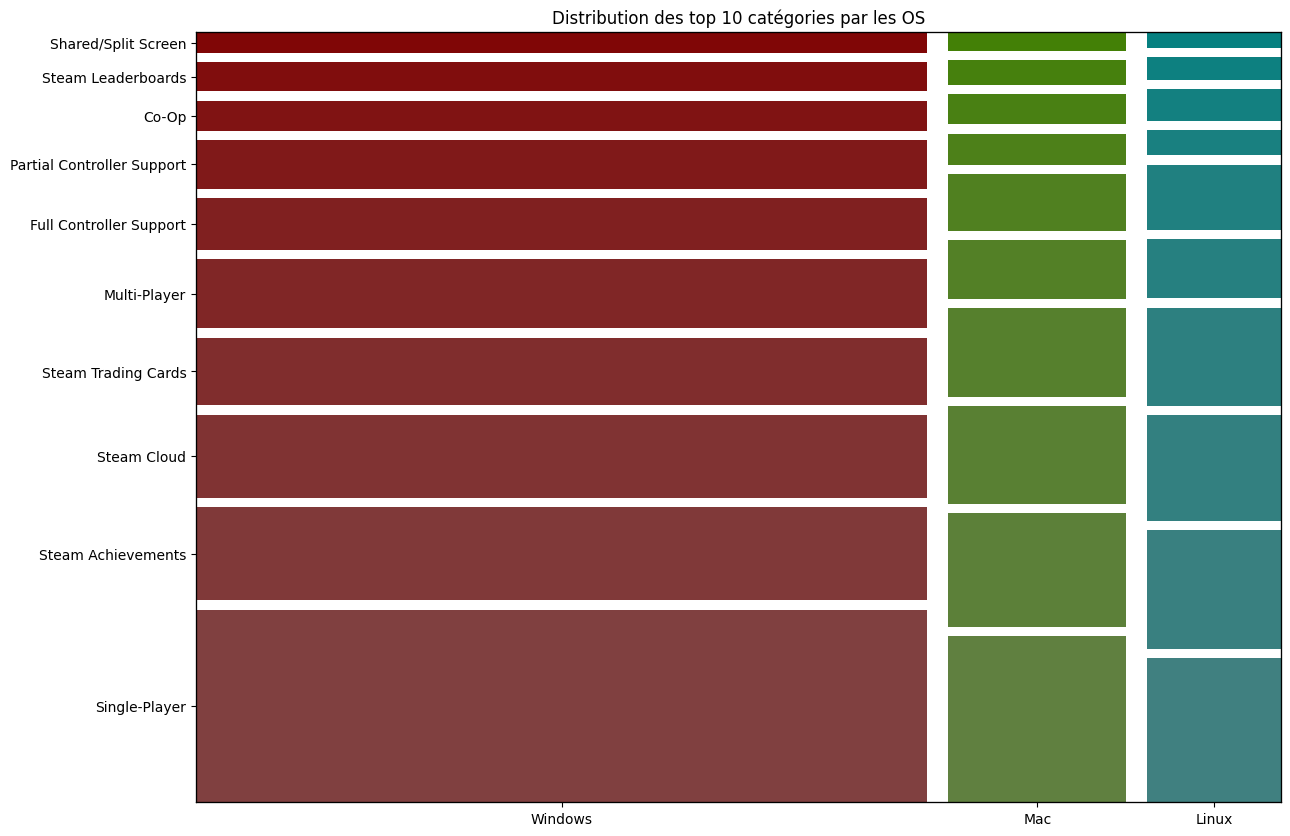

,os,categorie
3,Windows,Single-Player
4,Windows,Single-Player
6,Windows,Single-Player
12,Windows,Single-Player
21,Windows,Single-Player
...,...,...
3162,Linux,Shared/Split Screen
3516,Linux,Shared/Split Screen
3919,Linux,Shared/Split Screen
4176,Linux,Shared/Split Screen


In [81]:
plot_mosaic('os', 'os', 'categorie', 'categorie', top_n_x=3, top_n_y=10, custom_title="Distribution des top 10 catégories par les OS")